# Experiment 1: Grasp Stability under Partial Observations

**Goal**: Test whether additional sensory signals (contact force + proprioception) improve grasp stability compared to a vision-only policy.

**Ablation**:
- **Obs A** (baseline): object position + gripper position
- **Obs B** (augmented): Obs A + contact force + joint positions/velocities

Same policy architecture, same reward, same physics — only the observation space changes.

**Environment**: MuJoCo via `gymnasium` + `mujoco` (free on Kaggle GPU)

**Pipeline**: State → Observation → Policy (PPO) → Action → MuJoCo step → new state

## 1. Install dependencies

In [38]:
!pip install -q mujoco gymnasium stable-baselines3 shimmy matplotlib

## 2. Imports

In [39]:
import numpy as np
import mujoco
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv
import os, warnings
warnings.filterwarnings('ignore')
print('All imports OK')

All imports OK


## 3. MuJoCo XML model — 2-finger gripper + object

Simple parallel-jaw gripper grasping a small box. The gripper has 2 actuated finger joints.
The object is free-floating — it falls if not grasped.

In [49]:
GRASP_XML = r"""
<mujoco model="grasp_experiment_realistic">
  <compiler angle="degree" coordinate="local"/>
  <option timestep="0.002" gravity="0 0 -9.81" integrator="RK4"/>

  <default>
    <joint damping="1.5" armature="0.01" limited="true"/>
    <geom solref="0.004 1"
          solimp="0.95 0.99 0.001"
          friction="1.1 0.03 0.01"
          density="800"/>
    <site size="0.004" rgba="1 0 0 1"/>
  </default>

  <asset>
    <texture type="skybox" builtin="gradient"
             rgb1="0.4 0.6 0.8" rgb2="0 0 0"
             width="512" height="512"/>
    <material name="table_mat"  rgba="0.75 0.72 0.68 1"/>
    <material name="finger_mat" rgba="0.20 0.70 0.20 1"/>
    <material name="object_mat" rgba="0.90 0.40 0.10 1"/>
  </asset>

  <worldbody>
    <!-- Floor -->
    <geom name="floor"
          type="plane"
          size="2 2 0.1"
          rgba="0.9 0.9 0.9 1"
          contype="1"
          conaffinity="1"/>

    <!-- Table -->
    <body name="table" pos="0 0 0.18">
      <geom name="table_top"
            type="box"
            size="0.22 0.22 0.02"
            material="table_mat"
            friction="0.8 0.02 0.01"
            contype="1"
            conaffinity="3"/>
    </body>

    <!-- Fixed gripper mount -->
    <body name="gripper_base" pos="0 0 0.34">
      <geom name="base"
            type="box"
            size="0.045 0.03 0.02"
            rgba="0.3 0.3 0.8 1"
            mass="0.4"
            contype="0"
            conaffinity="0"/>

      <!-- Left finger -->
      <body name="left_finger" pos="-0.05 0 -0.01">
        <joint name="left_finger_joint"
               type="slide"
               axis="1 0 0"
               range="-0.035 0.035"/>

        <geom name="left_finger_link"
              type="box"
              size="0.012 0.012 0.05"
              pos="0 0 -0.03"
              material="finger_mat"
              mass="0.06"
              friction="1.0 0.03 0.01"
              contype="1"
              conaffinity="2"/>

        <geom name="left_finger_pad"
              type="capsule"
              fromto="0 0 -0.07 0 0 -0.10"
              size="0.009"
              rgba="0.15 0.65 0.15 1"
              mass="0.015"
              friction="1.4 0.04 0.015"
              contype="1"
              conaffinity="2"/>

        <site name="left_tip" pos="0 0 -0.10"/>
      </body>

      <!-- Right finger -->
      <body name="right_finger" pos="0.05 0 -0.01">
        <joint name="right_finger_joint"
               type="slide"
               axis="-1 0 0"
               range="-0.035 0.035"/>

        <geom name="right_finger_link"
              type="box"
              size="0.012 0.012 0.05"
              pos="0 0 -0.03"
              material="finger_mat"
              mass="0.06"
              friction="1.0 0.03 0.01"
              contype="1"
              conaffinity="2"/>

        <geom name="right_finger_pad"
              type="capsule"
              fromto="0 0 -0.07 0 0 -0.10"
              size="0.009"
              rgba="0.15 0.65 0.15 1"
              mass="0.015"
              friction="1.4 0.04 0.015"
              contype="1"
              conaffinity="2"/>

        <site name="right_tip" pos="0 0 -0.10"/>
      </body>
    </body>

    <!-- Object: rectangular, heavier, slightly off-center -->
    <body name="object" pos="0.008 -0.006 0.225">
      <freejoint name="object_joint"/>
      <geom name="object_geom"
            type="box"
            size="0.022 0.028 0.032"
            material="object_mat"
            mass="0.11"
            friction="0.9 0.025 0.008"
            contype="2"
            conaffinity="3"/>
      <site name="object_site" pos="0 0 0"/>
    </body>
  </worldbody>

  <actuator>
    <position name="left_act"
              joint="left_finger_joint"
              kp="70"
              ctrlrange="-0.035 0.035"/>
    <position name="right_act"
              joint="right_finger_joint"
              kp="70"
              ctrlrange="-0.035 0.035"/>
  </actuator>

  <sensor>
    <force name="left_force" site="left_tip"/>
    <force name="right_force" site="right_tip"/>
    <touch name="left_touch" site="left_tip"/>
    <touch name="right_touch" site="right_tip"/>
  </sensor>
</mujoco>
"""

## 4. Gymnasium environment

Two observation modes selected by `obs_mode='vision'` or `'vision_tactile'`.

**Reward** — shaped to encourage:
1. Closing fingers around the object
2. Lifting the object (z-height bonus)
3. Penalising object falling below a height threshold

In [50]:
class GraspEnv(gym.Env):
    """
    Grasp stability environment.

    obs_mode: 'vision'          -> [obj_pos(3), gripper_pos(3)]              dim=6
              'vision_tactile'  -> [obj_pos(3), gripper_pos(3),
                                    contact_forces(6), joint_pos(2), joint_vel(2)]  dim=16

    Fixes applied
    -------------
    Bug 3: finger init signs flipped — fingers now start OPEN (spread apart),
           so the object is captured rather than pushed away.
    Bug 4: OBJ_INIT_POS z raised from 0.320 → 0.360 to sit inside finger workspace.
    Bug 1: ctrlrange tightened to match object half-width (25 mm); action_space updated.
    Bug 2: r_aperture replaced with a Gaussian reward centred on target grip width,
           eliminating the conflict with the contact reward.
    """
    metadata = {"render_modes": []}

    # Bug 4 fix: raise object to finger workspace (fingers tips at ~0.36)
    OBJ_INIT_POS   = np.array([0.0, 0.0, 0.360], dtype=np.float32)
    FALL_THRESHOLD = 0.20
    MAX_STEPS      = 100

    # Bug 1 fix: target aperture = object half-width (25 mm each side)
    TARGET_HALF_APERTURE = 0.026   # just outside 25 mm object half-width

    def __init__(self, obs_mode="vision"):
        super().__init__()
        assert obs_mode in ("vision", "vision_tactile")
        self.obs_mode = obs_mode

        self.model = mujoco.MjModel.from_xml_string(GRASP_XML)
        self.data  = mujoco.MjData(self.model)

        # IDs
        self._obj_id = mujoco.mj_name2id(
            self.model, mujoco.mjtObj.mjOBJ_BODY, "object"
        )
        self._obj_jid = mujoco.mj_name2id(
            self.model, mujoco.mjtObj.mjOBJ_JOINT, "object_joint"
        )
        self._left_jid = mujoco.mj_name2id(
            self.model, mujoco.mjtObj.mjOBJ_JOINT, "left_finger_joint"
        )
        self._right_jid = mujoco.mj_name2id(
            self.model, mujoco.mjtObj.mjOBJ_JOINT, "right_finger_joint"
        )

        self._left_tip_sid = mujoco.mj_name2id(
            self.model, mujoco.mjtObj.mjOBJ_SITE, "left_tip"
        )
        self._right_tip_sid = mujoco.mj_name2id(
            self.model, mujoco.mjtObj.mjOBJ_SITE, "right_tip"
        )

        self._lf_sid = mujoco.mj_name2id(
            self.model, mujoco.mjtObj.mjOBJ_SENSOR, "left_force"
        )
        self._rf_sid = mujoco.mj_name2id(
            self.model, mujoco.mjtObj.mjOBJ_SENSOR, "right_force"
        )

        self._left_qpos_adr  = self.model.jnt_qposadr[self._left_jid]
        self._right_qpos_adr = self.model.jnt_qposadr[self._right_jid]
        self._left_qvel_adr  = self.model.jnt_dofadr[self._left_jid]
        self._right_qvel_adr = self.model.jnt_dofadr[self._right_jid]
        self._obj_qpos_adr   = self.model.jnt_qposadr[self._obj_jid]

        obs_dim = 6 if obs_mode == "vision" else 16
        high = np.full(obs_dim, np.inf, dtype=np.float32)
        self.observation_space = spaces.Box(-high, high, dtype=np.float32)

        # Action space: keep full ±0.03 range so policy can overshoot object and squeeze
        lim = self.TARGET_HALF_APERTURE
        self.action_space = spaces.Box(
            low=np.array([-lim, -lim], dtype=np.float32),
            high=np.array([ lim,  lim], dtype=np.float32),
            dtype=np.float32,
        )

        self._step = 0

    def _obj_pos(self):
        return self.data.xpos[self._obj_id].copy()

    def _gripper_pos(self):
        l = self.data.site_xpos[self._left_tip_sid]
        r = self.data.site_xpos[self._right_tip_sid]
        return ((l + r) / 2.0).copy()

    def _contact_forces(self):
        lf_adr = self.model.sensor_adr[self._lf_sid]
        rf_adr = self.model.sensor_adr[self._rf_sid]
        lf_dim = self.model.sensor_dim[self._lf_sid]
        rf_dim = self.model.sensor_dim[self._rf_sid]

        lf = self.data.sensordata[lf_adr:lf_adr + lf_dim].copy()
        rf = self.data.sensordata[rf_adr:rf_adr + rf_dim].copy()
        return np.concatenate([lf, rf]).astype(np.float32)

    def _joint_state(self):
        lp = self.data.qpos[self._left_qpos_adr]
        rp = self.data.qpos[self._right_qpos_adr]
        lv = self.data.qvel[self._left_qvel_adr]
        rv = self.data.qvel[self._right_qvel_adr]
        return np.array([lp, rp, lv, rv], dtype=np.float32)

    def _get_obs(self):
        base = np.concatenate([
            self._obj_pos().astype(np.float32),
            self._gripper_pos().astype(np.float32),
        ])
        if self.obs_mode == "vision":
            return base
        return np.concatenate([
            base,
            self._contact_forces(),
            self._joint_state(),
        ]).astype(np.float32)

    def _reward(self):
        obj_pos  = self._obj_pos()
        grip_pos = self._gripper_pos()
        obj_z    = obj_pos[2]

        dist_xy = np.linalg.norm(obj_pos[:2] - grip_pos[:2])
        r_align = np.exp(-12.0 * dist_xy)

        # Keep object high
        r_height = np.clip(
            (obj_z - self.FALL_THRESHOLD) / (0.38 - self.FALL_THRESHOLD), 0.0, 1.0
        )

        lp = self.data.qpos[self._left_qpos_adr]
        rp = self.data.qpos[self._right_qpos_adr]
        aperture = abs(rp - lp)

        # Bug 2 fix: Gaussian reward centred on target grip width.
        # Rewards the policy for settling at the right aperture rather than
        # fully closing (which conflicts with the contact reward).
        target_aperture = 2 * self.TARGET_HALF_APERTURE
        r_aperture = np.exp(-200.0 * (aperture - target_aperture) ** 2)

        cf = self._contact_forces()
        left_contact  = np.linalg.norm(cf[:3])
        right_contact = np.linalg.norm(cf[3:])
        both_contact  = float(left_contact > 0.05 and right_contact > 0.05)

        reward = (
            0.8 * r_align
            + 1.5 * r_height
            + 0.6 * r_aperture      # slightly up-weighted now that conflict is gone
            + 1.2 * both_contact
        )

        # Explicit drop penalty
        if obj_z < self.FALL_THRESHOLD:
            reward -= 5.0

        return float(reward)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        mujoco.mj_resetData(self.model, self.data)

        rng = np.random.default_rng(seed)

        # Bug 3 fix: fingers start OPEN (spread wider than the object)
        # so the object sits between them at reset, not outside them.
        lim = self.TARGET_HALF_APERTURE
        self.data.qpos[self._left_qpos_adr]  = -lim   # left slides LEFT (outward)
        self.data.qpos[self._right_qpos_adr] =  lim   # right slides RIGHT (outward)
        self.data.qvel[self._left_qvel_adr]  = 0.0
        self.data.qvel[self._right_qvel_adr] = 0.0

        obj_pos = self.OBJ_INIT_POS.copy()
        obj_pos[:2] += rng.uniform(-0.006, 0.006, size=2)

        self.data.qpos[self._obj_qpos_adr:self._obj_qpos_adr + 3] = obj_pos
        self.data.qpos[self._obj_qpos_adr + 3:self._obj_qpos_adr + 7] = [1, 0, 0, 0]
        self.data.qvel[:] = 0.0

        mujoco.mj_forward(self.model, self.data)

        self._step = 0
        return self._get_obs(), {}

    def step(self, action):
        action = np.asarray(action, dtype=np.float32)
        action = np.clip(action, self.action_space.low, self.action_space.high)

        self.data.ctrl[:] = action

        for _ in range(5):
            mujoco.mj_step(self.model, self.data)

        obs    = self._get_obs()
        reward = self._reward()
        obj_z  = float(self._obj_pos()[2])

        terminated = bool(obj_z < self.FALL_THRESHOLD)
        self._step += 1
        truncated = bool(self._step >= self.MAX_STEPS)

        info = {
            "obj_z":          obj_z,
            "contact_forces": self._contact_forces(),
        }
        return obs, reward, terminated, truncated, info


for mode in ["vision", "vision_tactile"]:
    env = GraspEnv(obs_mode=mode)
    check_env(env, warn=True)
    obs, _ = env.reset(seed=0)
    print(f"[{mode}] obs shape: {obs.shape}, action shape: {env.action_space.shape}")
    obs, r, term, trunc, info = env.step(env.action_space.sample())
    print(f"  reward={r:.4f}, obj_z={info['obj_z']:.4f}")
    env.close()

print("Environment checks passed")


[vision] obs shape: (6,), action shape: (2,)
  reward=3.7558, obj_z=0.3606
[vision_tactile] obs shape: (16,), action shape: (2,)
  reward=3.7576, obj_z=0.3605
Environment checks passed


## 5. Training — PPO on both observation modes

We train identical PPO policies. The only difference is the observation space.
This is the core ablation.

In [51]:
import os
import warnings
warnings.filterwarnings('ignore')

TOTAL_TIMESTEPS = 200_000
LOG_DIR = os.path.join(os.getcwd(), 'logs')
os.makedirs(LOG_DIR, exist_ok=True)

def make_env(obs_mode, seed=0):
    def _init():
        env = GraspEnv(obs_mode=obs_mode)
        env.reset(seed=seed)          # seed used here
        env = Monitor(env, filename=os.path.join(LOG_DIR, obs_mode))
        return env
    return _init

# PPO hyperparameters — kept identical across both runs
PPO_KWARGS = dict(
    policy          = 'MlpPolicy',
    learning_rate   = 3e-4,
    n_steps         = 1024,
    batch_size      = 256,
    n_epochs        = 10,
    gamma           = 0.99,
    gae_lambda      = 0.95,
    clip_range      = 0.2,
    verbose         = 0,
    tensorboard_log = LOG_DIR,
)

models = {}
for obs_mode in ['vision', 'vision_tactile']:
    print(f'\n=== Training: {obs_mode} ===')
    vec_env = DummyVecEnv([make_env(obs_mode)])
    model   = PPO(env=vec_env, **PPO_KWARGS)
    model.learn(
        total_timesteps = TOTAL_TIMESTEPS,
        tb_log_name     = obs_mode,
    )
    save_path = os.path.join(os.getcwd(), f'ppo_{obs_mode}')
    model.save(save_path)
    models[obs_mode] = model
    vec_env.close()
    print(f'Saved: ppo_{obs_mode}.zip')



=== Training: vision ===
Saved: ppo_vision.zip

=== Training: vision_tactile ===
Saved: ppo_vision_tactile.zip


## 6. Evaluation

Run N evaluation episodes for each policy. Log:
- Episode return
- Fraction of episodes where object was held for full episode (no drop)
- Mean object height over episode

In [52]:
# Load saved models if not already in memory (e.g. after kernel restart)
if 'models' not in dir() or not models:
    models = {}
    for obs_mode in ['vision', 'vision_tactile']:
        path = os.path.join(os.getcwd(), f'ppo_{obs_mode}.zip')
        if os.path.exists(path):
            models[obs_mode] = PPO.load(path)
            print(f'Loaded {path}')
        else:
            print(f'WARNING: {path} not found — run training cell first')

def evaluate_policy(model, obs_mode, n_episodes=50, seed_offset=1000):
    env = GraspEnv(obs_mode=obs_mode)
    results = {
        "returns":      [],
        "survived":     [],
        "mean_obj_z":   [],
        "final_obj_z":  [],
        "steps_alive":  [],
    }

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed_offset + ep)
        done = False
        ep_ret = 0.0
        zs = []
        steps = 0
        dropped = False

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, info = env.step(action)
            ep_ret += r
            zs.append(info["obj_z"])
            steps += 1

            if term:
                dropped = True

            done = term or trunc

        results["returns"].append(ep_ret)
        results["survived"].append(0 if dropped else 1)
        results["mean_obj_z"].append(np.mean(zs))
        results["final_obj_z"].append(zs[-1])
        results["steps_alive"].append(steps)

    env.close()
    return {k: np.array(v) for k, v in results.items()}


eval_results = {}
for obs_mode, model in models.items():
    print(f"Evaluating {obs_mode}...")
    r = evaluate_policy(model, obs_mode, n_episodes=50)
    eval_results[obs_mode] = r
    print(f'  Mean return:    {r["returns"].mean():.2f} ± {r["returns"].std():.2f}')
    print(f'  Survival rate:  {r["survived"].mean()*100:.1f}%')
    print(f'  Mean obj z:     {r["mean_obj_z"].mean():.4f} m')
    print(f'  Steps alive:    {r["steps_alive"].mean():.1f} / {GraspEnv.MAX_STEPS}')


Evaluating vision...
  Mean return:    287.20 ± 3.70
  Survival rate:  100.0%
  Mean obj z:     0.2442 m
  Steps alive:    100.0 / 100
Evaluating vision_tactile...
  Mean return:    292.50 ± 3.86
  Survival rate:  100.0%
  Mean obj z:     0.2514 m
  Steps alive:    100.0 / 100


## 7. Results visualisation

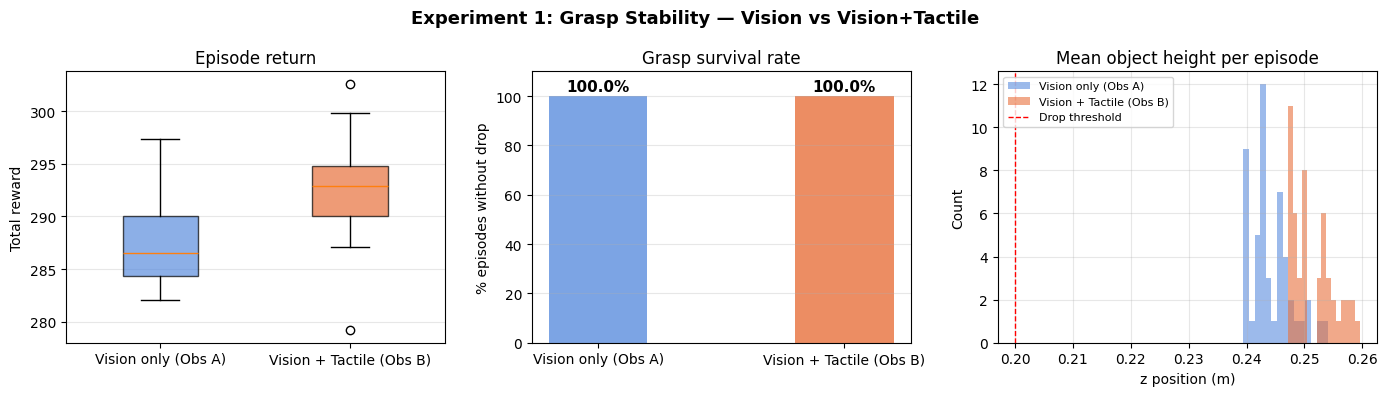

Figure saved to /kaggle/working/experiment1_results.png


In [53]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Experiment 1: Grasp Stability — Vision vs Vision+Tactile', fontsize=13, fontweight='bold')

modes  = list(eval_results.keys())
colors = ['#5B8DDE', '#E8713C']
labels = ['Vision only (Obs A)', 'Vision + Tactile (Obs B)']

# --- Plot 1: Episode returns (box plot) ---
ax = axes[0]
data_to_plot = [eval_results[m]['returns'] for m in modes]
bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, widths=0.4)
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_title('Episode return')
ax.set_ylabel('Total reward')
ax.grid(axis='y', alpha=0.3)

# --- Plot 2: Survival rate ---
ax = axes[1]
survival_rates = [eval_results[m]['survived'].mean() * 100 for m in modes]
bars = ax.bar(labels, survival_rates, color=colors, alpha=0.8, width=0.4)
for bar, v in zip(bars, survival_rates):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Grasp survival rate')
ax.set_ylabel('% episodes without drop')
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)

# --- Plot 3: Mean object height distribution ---
ax = axes[2]
for m, c, lbl in zip(modes, colors, labels):
    ax.hist(eval_results[m]['mean_obj_z'], bins=15, alpha=0.6, color=c, label=lbl)
ax.axvline(x=0.20, color='red', linestyle='--', linewidth=1, label='Drop threshold')
ax.set_title('Mean object height per episode')
ax.set_xlabel('z position (m)')
ax.set_ylabel('Count')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
out_path = os.path.join(os.getcwd(), 'experiment1_results.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to {out_path}')


## 8. Summary statistics table

In [54]:
import pandas as pd

rows = []
for m, lbl in zip(modes, labels):
    r = eval_results[m]
    rows.append({
        'Observation mode':  lbl,
        'Mean return':       f"{r['returns'].mean():.2f}",
        'Std return':        f"{r['returns'].std():.2f}",
        'Survival rate (%)': f"{r['survived'].mean()*100:.1f}",
        'Mean obj z (m)':    f"{r['mean_obj_z'].mean():.4f}",
        'Final obj z (m)':   f"{r['final_obj_z'].mean():.4f}",
    })

df = pd.DataFrame(rows).set_index('Observation mode')
print(df.to_string())
csv_path = os.path.join(os.getcwd(), 'experiment1_summary.csv')
df.to_csv(csv_path)
print(f'Saved to {csv_path}')


                         Mean return Std return Survival rate (%) Mean obj z (m) Final obj z (m)
Observation mode                                                                                
Vision only (Obs A)           287.20       3.70             100.0         0.2442          0.2265
Vision + Tactile (Obs B)      292.50       3.86             100.0         0.2514          0.2266
Saved to /kaggle/working/experiment1_summary.csv


## 9. One evaluation rollout — render contact forces

Run one episode for the vision+tactile policy and plot contact forces over time.
This shows whether the policy is actively using tactile information.

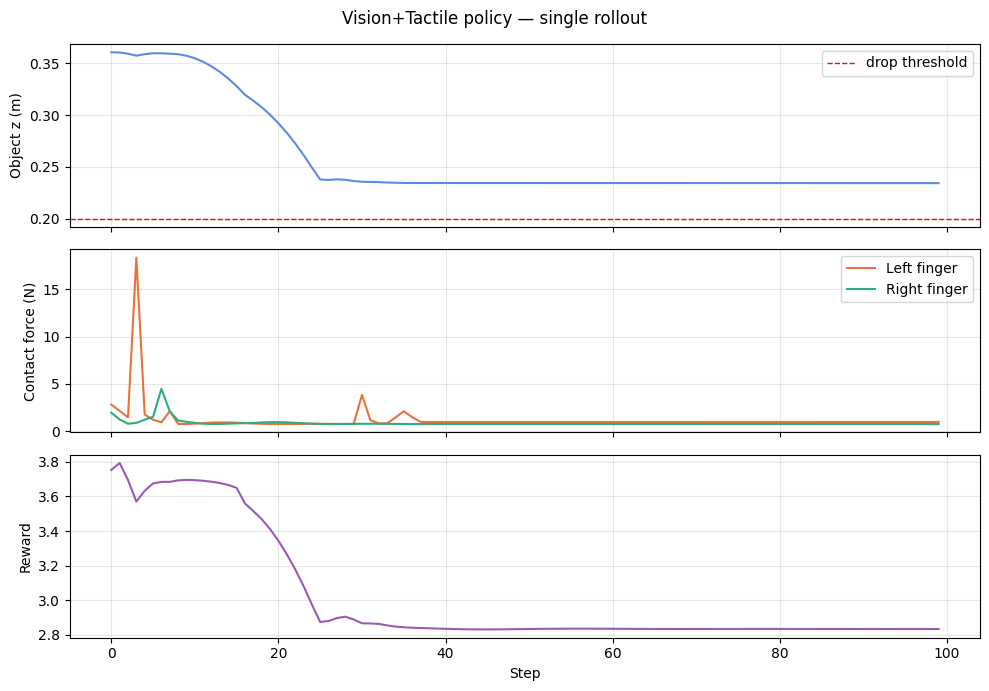

Saved to /kaggle/working/experiment1_rollout.png


In [55]:
def rollout_with_forces(model_ppo, obs_mode, seed=42):
    env = GraspEnv(obs_mode=obs_mode)
    obs, _ = env.reset(seed=seed)
    done = False
    forces_l, forces_r, heights, rewards = [], [], [], []

    while not done:
        action, _ = model_ppo.predict(obs, deterministic=True)
        obs, r, term, trunc, info = env.step(action)
        cf = info['contact_forces']
        forces_l.append(np.linalg.norm(cf[:3]))
        forces_r.append(np.linalg.norm(cf[3:]))
        heights.append(info['obj_z'])
        rewards.append(r)
        done = term or trunc
    env.close()
    return {
        'forces_l': np.array(forces_l),
        'forces_r': np.array(forces_r),
        'heights':  np.array(heights),
        'rewards':  np.array(rewards),
    }


rollout = rollout_with_forces(models['vision_tactile'], 'vision_tactile', seed=42)
t = np.arange(len(rollout['heights']))

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
fig.suptitle('Vision+Tactile policy — single rollout', fontsize=12)

ax1.plot(t, rollout['heights'], color='#5B8DDE')
ax1.axhline(0.20, color='red', linestyle='--', linewidth=1, label='drop threshold')
ax1.set_ylabel('Object z (m)'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(t, rollout['forces_l'], label='Left finger', color='#E8713C')
ax2.plot(t, rollout['forces_r'], label='Right finger', color='#2EAE7D')
ax2.set_ylabel('Contact force (N)'); ax2.legend(); ax2.grid(alpha=0.3)

ax3.plot(t, rollout['rewards'], color='#9B59B6')
ax3.set_ylabel('Reward'); ax3.set_xlabel('Step'); ax3.grid(alpha=0.3)

plt.tight_layout()
out_path = os.path.join(os.getcwd(), 'experiment1_rollout.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {out_path}')


## 10. Findings template

Fill in after running the experiment.

In [60]:
# Auto-generate a brief findings text
vr = eval_results.get('vision', {})
tr = eval_results.get('vision_tactile', {})

if vr and tr:
    delta_survival = tr['survived'].mean() - vr['survived'].mean()
    delta_return   = tr['returns'].mean()  - vr['returns'].mean()

    print('=== EXPERIMENT 1 FINDINGS ===')
    print(f'Survival rate delta:    {delta_survival*100:+.1f} pp  (tactile - vision)')
    print(f'Mean return delta:      {delta_return:+.2f}')
    print()
    print('Hypothesis: vision sufficient for reaching, touch necessary for stable grasping')

    if delta_survival > 0:
        survival_msg = 'Vision+Tactile performed better on survival rate'
    elif delta_survival < 0:
        survival_msg = 'Vision-only performed better on survival rate'
    else:
        survival_msg = 'No difference in survival rate'

    if delta_return > 0:
        return_msg = 'tactile achieved higher mean return'
    elif delta_return < 0:
        return_msg = 'vision-only achieved higher mean return'
    else:
        return_msg = 'no difference in mean return'

    if delta_survival == 0 and delta_return > 0:
        final_msg = 'No survival-rate difference; tactile achieved higher mean return'
    elif delta_survival == 0 and delta_return < 0:
        final_msg = 'No survival-rate difference; vision-only achieved higher mean return'
    elif delta_survival > 0 and delta_return > 0:
        final_msg = 'Tactile outperformed vision on both survival and return'
    elif delta_survival < 0 and delta_return < 0:
        final_msg = 'Vision-only outperformed tactile on both survival and return'
    else:
        final_msg = f'{survival_msg}; {return_msg}'

    print(f'Preliminary evidence:   {final_msg}')
else:
    print("Missing eval_results entries for 'vision' and/or 'vision_tactile'. Run evaluation first.")

=== EXPERIMENT 1 FINDINGS ===
Survival rate delta:    +0.0 pp  (tactile - vision)
Mean return delta:      +5.30

Hypothesis: vision sufficient for reaching, touch necessary for stable grasping
Preliminary evidence:   No survival-rate difference; tactile achieved higher mean return
